# Session 5 — Data Storytelling & Dashboards

Runnable code from the **Build It**, **Experiment**, and **Mini Project** sections.
Run each cell top to bottom.

## 1. Build It — Core Code

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### 5.1 Generate a tidy sales DataFrame inline

In [2]:
rng = np.random.default_rng(42)
months = pd.date_range("2024-01-01", periods=12, freq="MS")
base = {"Alpha": 120, "Beta": 90, "Gamma": 60}

records = []
for product, start in base.items():
    for i, month in enumerate(months):
        trend = start * (1 + 0.04 * i)
        seasonal = 1 + 0.25 * np.sin(2 * np.pi * i / 12)
        revenue = trend * seasonal * rng.normal(1.0, 0.05)
        records.append({"month": month, "product": product, "revenue": round(revenue, 2)})

sales = pd.DataFrame(records)
sales.head()

,month,product,revenue
0,2024-01-01,Alpha,121.83
1,2024-02-01,Alpha,133.10
2,2024-03-01,Alpha,163.58
3,2024-04-01,Alpha,175.90
4,2024-05-01,Alpha,152.82


In [3]:
pivot = sales.pivot(index="month", columns="product", values="revenue")
total_by_product = sales.groupby("product")["revenue"].sum()
monthly_total = sales.groupby("month")["revenue"].sum()
pivot.head()

product,Alpha,Beta,Gamma
month,,,
2024-01-01,121.83,90.30,58.72
2024-02-01,133.10,111.23,68.96
2024-03-01,163.58,121.01,80.93
2024-04-01,175.90,120.59,85.53
2024-05-01,152.82,129.34,86.42


### 5.2 Plotting a DataFrame column, two ways

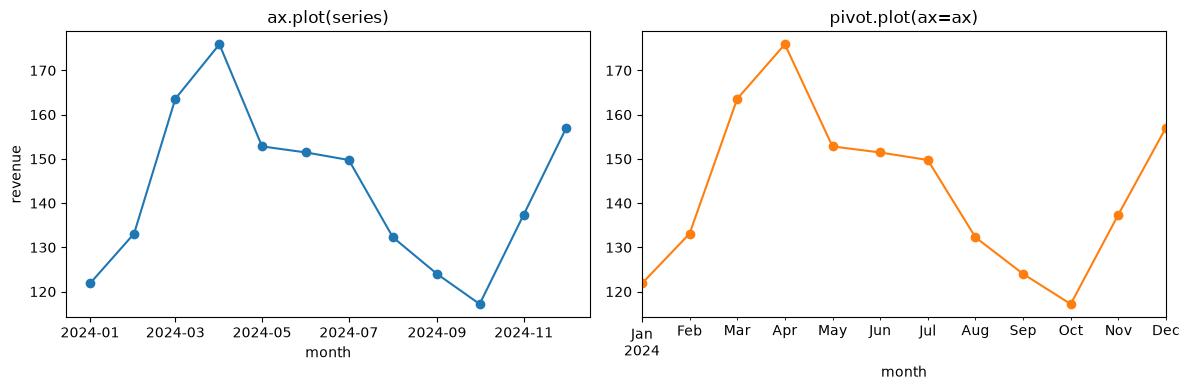

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(pivot.index, pivot["Alpha"], marker="o", color="C0")
axes[0].set_title("ax.plot(series)")
axes[0].set_xlabel("month")
axes[0].set_ylabel("revenue")

pivot.plot(y="Alpha", ax=axes[1], marker="o", color="C1", legend=False)
axes[1].set_title("pivot.plot(ax=ax)")
axes[1].set_xlabel("month")

fig.tight_layout()
plt.show()

### 5.3 A multi-panel grid

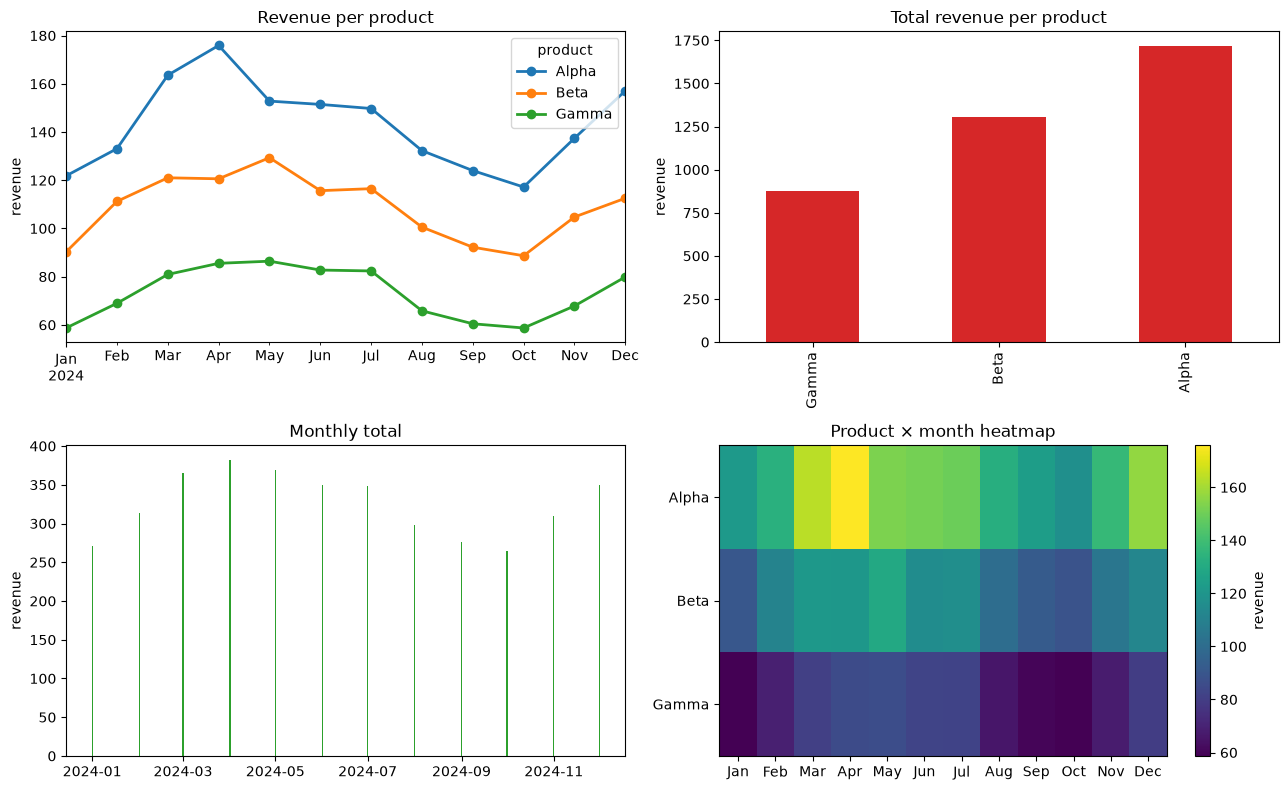

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

pivot.plot(ax=axes[0, 0], marker="o", linewidth=2)
axes[0, 0].set_title("Revenue per product")
axes[0, 0].set_ylabel("revenue")
axes[0, 0].set_xlabel("")

total_by_product.sort_values().plot.bar(ax=axes[0, 1], color="C3")
axes[0, 1].set_title("Total revenue per product")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("revenue")

axes[1, 0].bar(monthly_total.index, monthly_total.values, color="C2")
axes[1, 0].set_title("Monthly total")
axes[1, 0].set_ylabel("revenue")

im = axes[1, 1].imshow(pivot.T.values, aspect="auto", cmap="viridis")
axes[1, 1].set_yticks(range(len(pivot.columns)), labels=pivot.columns)
axes[1, 1].set_xticks(range(len(pivot.index)), labels=[m.strftime("%b") for m in pivot.index])
axes[1, 1].set_title("Product × month heatmap")
fig.colorbar(im, ax=axes[1, 1], label="revenue")

fig.tight_layout()
plt.show()

### 5.4 Shared axes

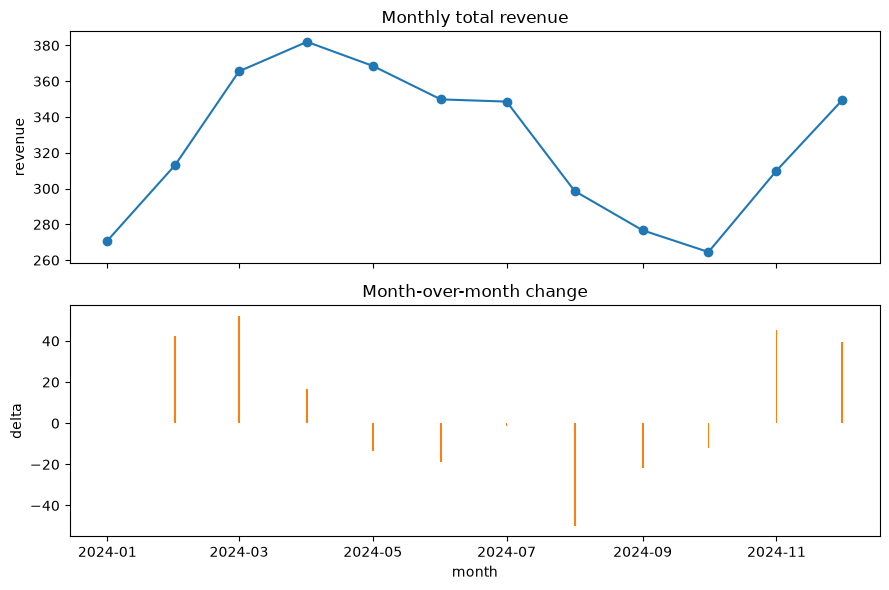

In [6]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(9, 6))

axes[0].plot(monthly_total.index, monthly_total.values, marker="o", color="C0")
axes[0].set_title("Monthly total revenue")
axes[0].set_ylabel("revenue")

axes[1].bar(monthly_total.index, monthly_total.diff().fillna(0), color="C1")
axes[1].set_title("Month-over-month change")
axes[1].set_ylabel("delta")
axes[1].set_xlabel("month")

fig.tight_layout()
plt.show()

### 5.5 Annotations: point at the finding

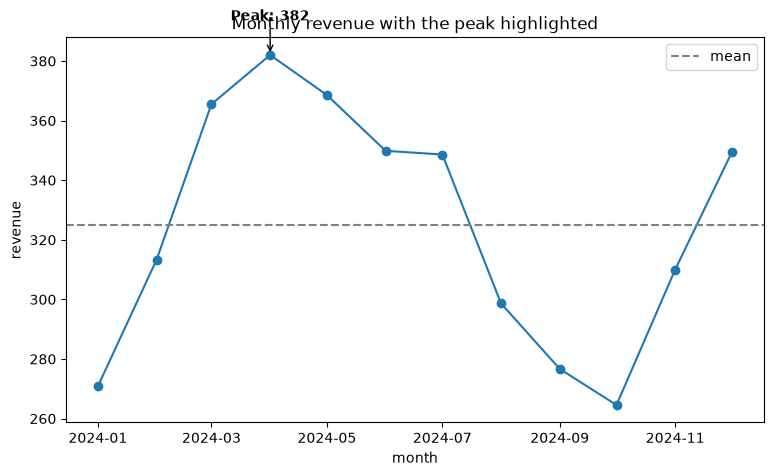

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(monthly_total.index, monthly_total.values, marker="o", color="C0")

peak_month = monthly_total.idxmax()
peak_value = monthly_total.max()

ax.annotate(
    f"Peak: {peak_value:,.0f}",
    xy=(peak_month, peak_value),
    xytext=(0, 25),
    textcoords="offset points",
    ha="center",
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="black"),
)
ax.axhline(monthly_total.mean(), linestyle="--", color="gray", label="mean")
ax.set_title("Monthly revenue with the peak highlighted")
ax.set_xlabel("month")
ax.set_ylabel("revenue")
ax.legend()
plt.show()

### 5.6 Titles, subtitles, and captions

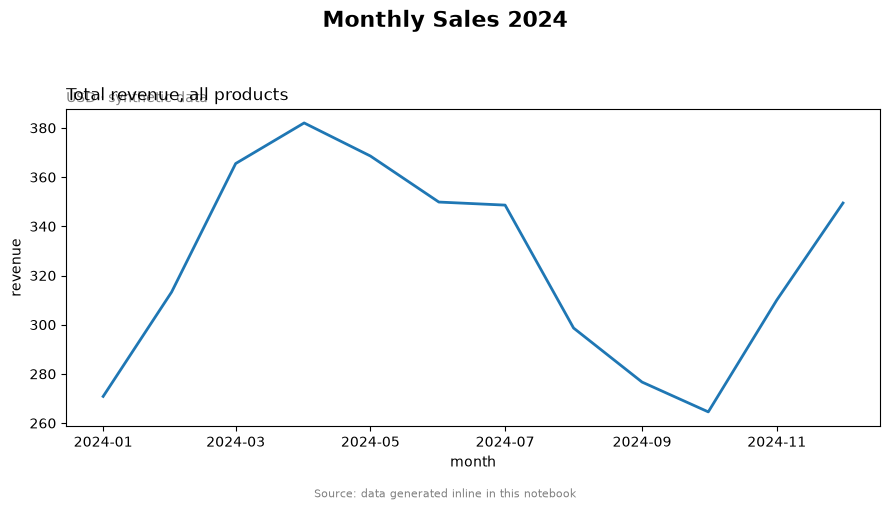

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(monthly_total.index, monthly_total.values, linewidth=2, color="C0")

fig.suptitle("Monthly Sales 2024", fontsize=16, fontweight="bold")
ax.set_title("Total revenue, all products", loc="left")
ax.text(0, 1.02, "USD · synthetic data", transform=ax.transAxes,
        fontsize=10, color="gray")
fig.text(0.5, 0.005, "Source: data generated inline in this notebook",
         ha="center", fontsize=8, color="gray")
ax.set_xlabel("month")
ax.set_ylabel("revenue")

fig.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

### 5.7 Saving at publication quality

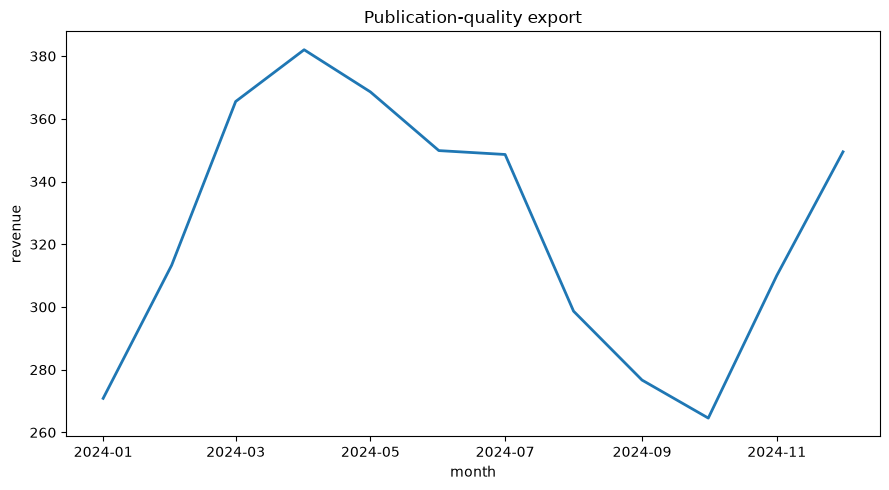

Saved and removed story_figure.png


In [9]:
import os

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(monthly_total.index, monthly_total.values, linewidth=2, color="C0")
ax.set_title("Publication-quality export")
ax.set_xlabel("month")
ax.set_ylabel("revenue")
fig.tight_layout()

fig.savefig("story_figure.png", dpi=300, bbox_inches="tight")
plt.show()

os.remove("story_figure.png")
print("Saved and removed story_figure.png")

## 2. Experiment

Try each experiment and predict the result *before* you run it.

#### Experiment 1: shared vs. independent y-axes

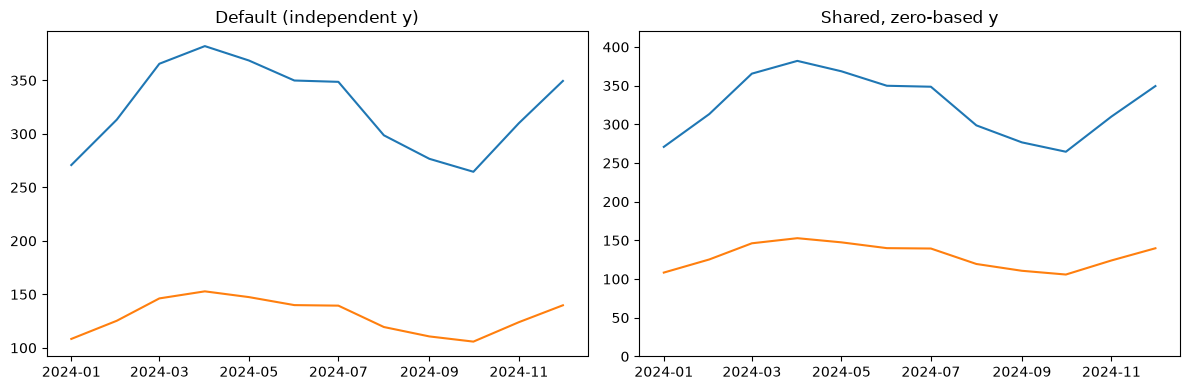

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(monthly_total.index, monthly_total.values, color="C0")
axes[0].plot(monthly_total.index, monthly_total.values * 0.4, color="C1")
axes[0].set_title("Default (independent y)")

axes[1].plot(monthly_total.index, monthly_total.values, color="C0")
axes[1].plot(monthly_total.index, monthly_total.values * 0.4, color="C1")
axes[1].set_ylim(0, monthly_total.max() * 1.1)
axes[1].set_title("Shared, zero-based y")
fig.tight_layout()
plt.show()

#### Experiment 2: `offset points` vs. data coordinates

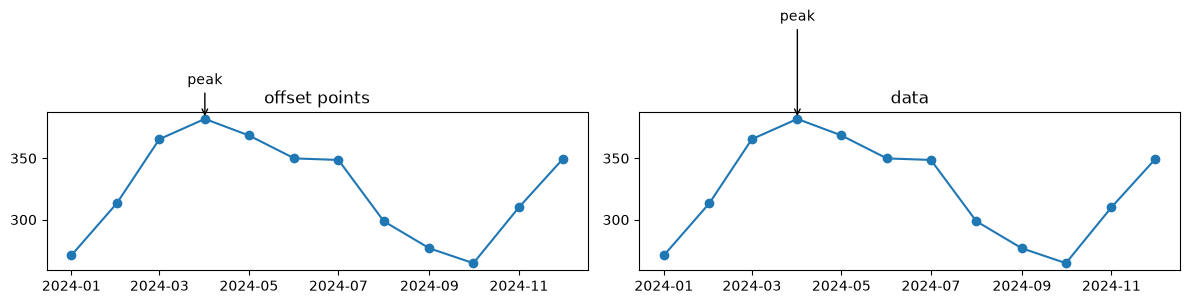

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, mode in zip(axes, ["offset points", "data"]):
    ax.plot(monthly_total.index, monthly_total.values, marker="o", color="C0")
    if mode == "offset points":
        ax.annotate("peak", xy=(peak_month, peak_value), xytext=(0, 25),
                    textcoords="offset points", ha="center",
                    arrowprops=dict(arrowstyle="->"))
    else:
        ax.annotate("peak", xy=(peak_month, peak_value),
                    xytext=(peak_month, peak_value + 80), ha="center",
                    arrowprops=dict(arrowstyle="->"))
    ax.set_title(mode)
fig.tight_layout()
plt.show()

#### Experiment 3: an honest bar baseline

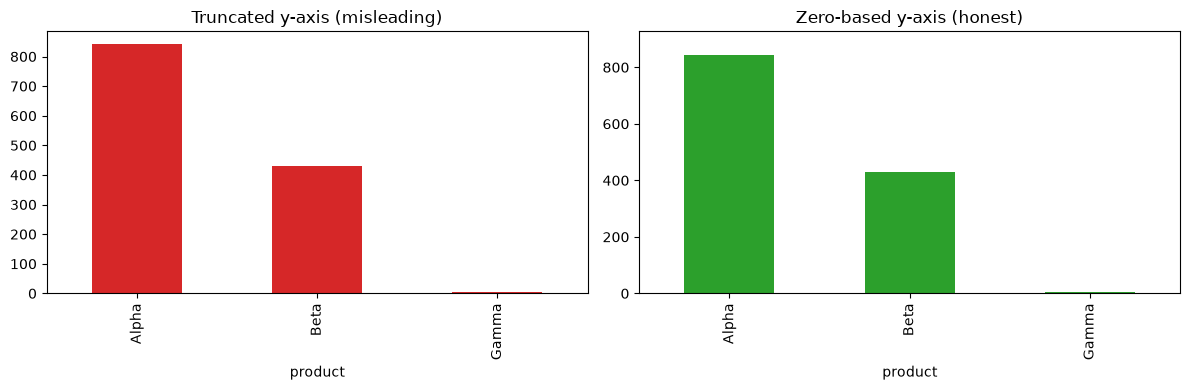

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
small = total_by_product - total_by_product.min() + 5

small.plot.bar(ax=axes[0], color="C3")
axes[0].set_title("Truncated y-axis (misleading)")

small.plot.bar(ax=axes[1], color="C2")
axes[1].set_ylim(0, small.max() * 1.1)
axes[1].set_title("Zero-based y-axis (honest)")
fig.tight_layout()
plt.show()

#### Experiment 4: swap a panel with `subplot_mosaic`

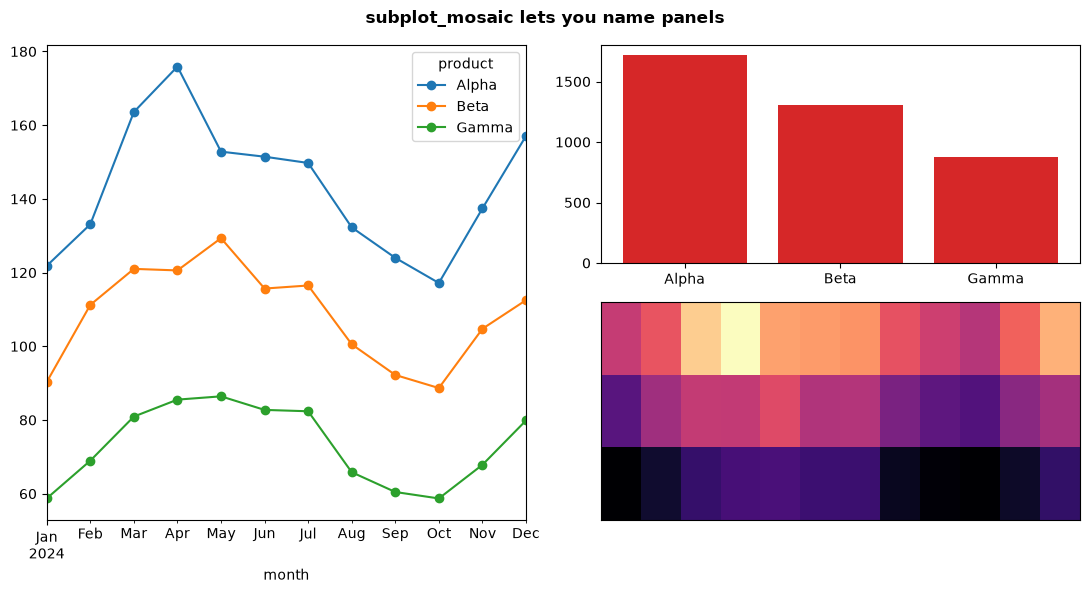

In [13]:
fig, axd = plt.subplot_mosaic(
    [["wide", "side"],
     ["wide", "square"]],
    figsize=(11, 6),
)
pivot.plot(ax=axd["wide"], marker="o")
axd["side"].bar(total_by_product.index, total_by_product.values, color="C3")
axd["square"].imshow(pivot.T.values, aspect="auto", cmap="magma")
axd["square"].set_xticks([])
axd["square"].set_yticks([])
fig.suptitle("subplot_mosaic lets you name panels", fontweight="bold")
fig.tight_layout()
plt.show()

## 3. Mini Project — Sales Dashboard

Assemble the four panels into one dashboard with a headline, per-panel titles,
an annotation, a source caption, and a publication-quality export.

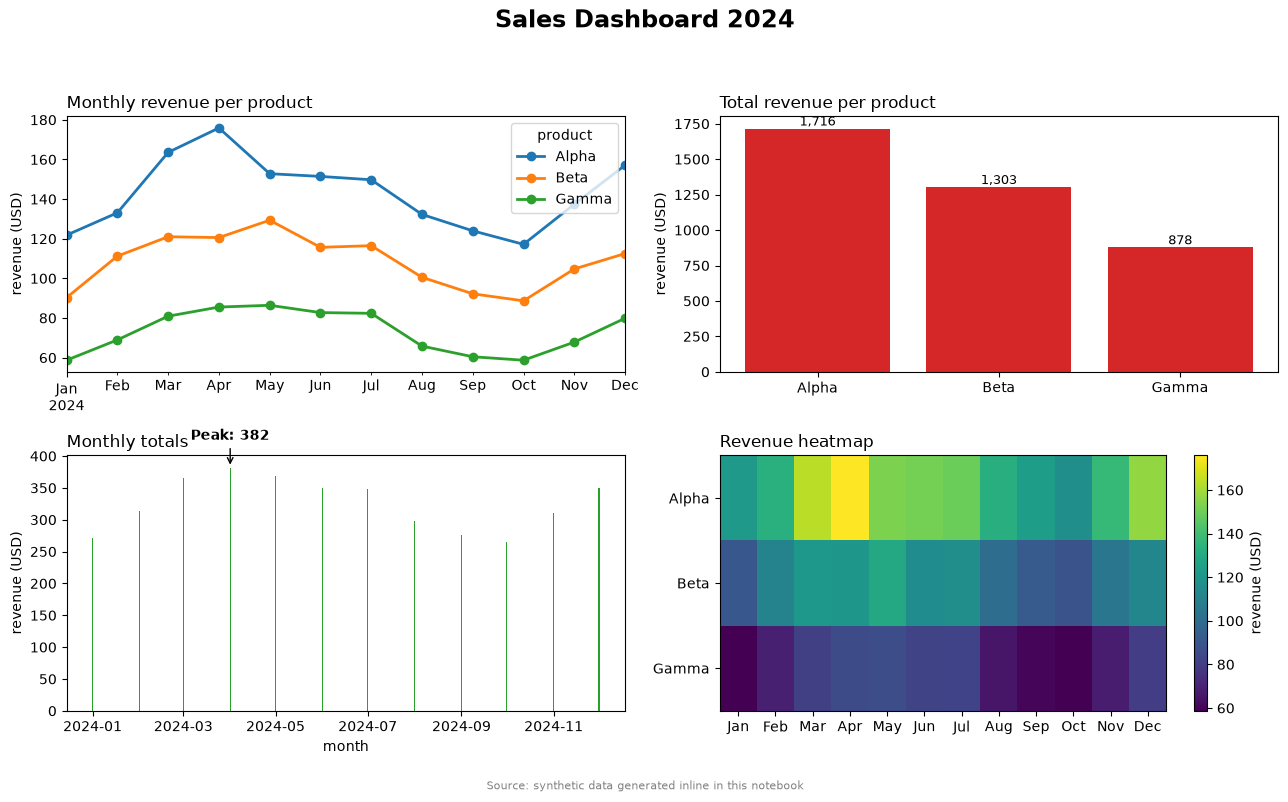

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# --- Top-left: revenue per product over time ---
pivot.plot(ax=axes[0, 0], marker="o", linewidth=2)
axes[0, 0].set_title("Monthly revenue per product", loc="left")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("revenue (USD)")

# --- Top-right: total revenue per product ---
ordered = total_by_product.sort_values(ascending=False)
axes[0, 1].bar(ordered.index, ordered.values, color="C3")
axes[0, 1].set_title("Total revenue per product", loc="left")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("revenue (USD)")
for label, value in zip(ordered.index, ordered.values):
    axes[0, 1].text(label, value, f"{value:,.0f}",
                    ha="center", va="bottom", fontsize=9)

# --- Bottom-left: monthly totals with the peak annotated ---
axes[1, 0].bar(monthly_total.index, monthly_total.values, color="C2")
axes[1, 0].set_title("Monthly totals", loc="left")
axes[1, 0].set_xlabel("month")
axes[1, 0].set_ylabel("revenue (USD)")
axes[1, 0].annotate(
    f"Peak: {peak_value:,.0f}",
    xy=(peak_month, peak_value),
    xytext=(0, 20),
    textcoords="offset points",
    ha="center",
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="black"),
)

# --- Bottom-right: product x month heatmap ---
heat = axes[1, 1].imshow(pivot.T.values, aspect="auto", cmap="viridis")
axes[1, 1].set_yticks(range(len(pivot.columns)), labels=pivot.columns)
axes[1, 1].set_xticks(range(len(pivot.index)),
                       labels=[m.strftime("%b") for m in pivot.index])
axes[1, 1].set_title("Revenue heatmap", loc="left")
fig.colorbar(heat, ax=axes[1, 1], label="revenue (USD)")

# --- Story layers ---
fig.suptitle("Sales Dashboard 2024", fontsize=17, fontweight="bold")
fig.text(0.5, 0.005, "Source: synthetic data generated inline in this notebook",
         ha="center", fontsize=8, color="gray")
fig.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.show()

In [15]:
# Export at publication quality, then clean up the file.
fig.savefig("sales_dashboard.png", dpi=200, bbox_inches="tight")
os.remove("sales_dashboard.png")
print("Saved and removed sales_dashboard.png")

Saved and removed sales_dashboard.png
